In [22]:
import numpy as np
import scipy
import scipy.integrate
import matplotlib.pyplot as plt
import pyreadr
import pandas as pd
import sympy as sp

#import M2 data
M2 = pyreadr.read_r('/Users/anjalishah/Desktop/Senior_Thesis/full_2018_data_M2_Bering_combined_data.RDS')
M2 = M2[None]

M2=M2.set_index(M2.index.astype(int))
M2

,time_ak,full_O2,full_saturation_O2,full_chla,full_temperature,full_salinity,full_doy,approxPAR,time_gmt,air_tempC,...,cb_mean_tempC_int,t,kz,N,h,do2_dz_at_MLD_smoothed_boosted,doy.y,fmlb_term_mumol_per_kg_per_second,h_smooth_meters,iz
0,2018-05-01 23:00:00,338.542823,93.850346,1.140632,3.707315,32.059670,121.0,NaN,2018-05-02 00:00:00,3.8,...,3.8,NaN,NaN,NaN,NaN,NaN,121,2.510000e-05,16.040017,600.0
1,2018-05-02 00:00:00,340.833953,94.420655,0.528858,3.685249,32.038726,121.0,1035.6077,2018-05-02 01:00:00,4.1,...,3.8,NaN,NaN,NaN,NaN,NaN,121,2.090000e-05,17.333108,600.0
2,2018-05-02 01:00:00,342.079872,94.662048,0.760485,3.644305,32.025575,121.0,1238.0130,2018-05-02 02:00:00,4.1,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.760000e-05,18.565663,600.0
3,2018-05-02 02:00:00,343.325790,94.903442,0.992112,3.603360,32.012424,121.0,1047.3983,2018-05-02 03:00:00,4.0,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.490000e-05,19.746918,600.0
4,2018-05-02 03:00:00,344.064635,94.893928,0.956638,3.517202,31.993301,121.0,646.5179,2018-05-02 04:00:00,3.6,...,3.8,NaN,NaN,NaN,NaN,NaN,121,1.270000e-05,20.883307,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3665,2018-10-01 16:00:00,283.044887,89.094355,3.606080,10.227915,31.844964,274.0,0.0000,2018-10-01 17:00:00,10.7,...,11.7,NaN,NaN,NaN,NaN,NaN,274,1.670000e-07,37.171765,600.0
3666,2018-10-01 17:00:00,283.266056,89.170021,3.766137,10.231230,31.844287,274.0,3.9302,2018-10-01 18:00:00,10.8,...,11.7,NaN,NaN,NaN,NaN,NaN,274,2.550000e-07,37.128667,600.0
3667,2018-10-01 18:00:00,283.487226,89.245686,3.926194,10.234544,31.843611,274.0,82.5342,2018-10-01 19:00:00,10.6,...,11.7,NaN,NaN,NaN,NaN,NaN,274,3.510000e-07,37.084248,600.0
3668,2018-10-01 19:00:00,283.693629,89.316676,3.999519,10.237335,31.844625,274.0,237.7771,2018-10-01 20:00:00,10.6,...,11.7,NaN,NaN,NaN,NaN,NaN,274,4.530000e-07,37.038501,600.0


Text(0, 0.5, 'Temp °C')

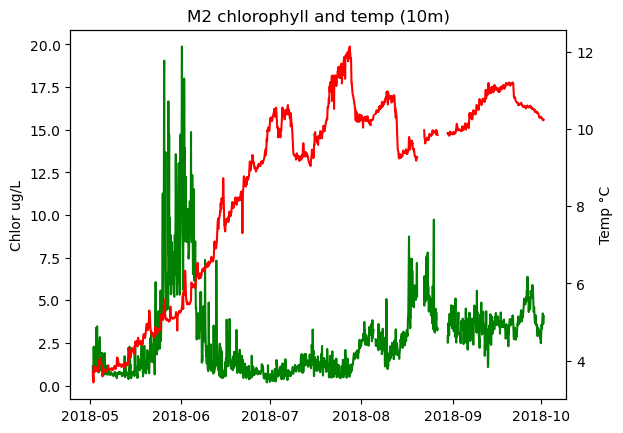

In [165]:
fig, ax1 = plt.subplots()
ax1.plot(M2['time_ak'], M2['full_chla'], color='green')
ax2 = ax1.twinx()
ax2.plot(M2['time_ak'], M2['full_temperature'], color='red')
plt.title('M2 chlorophyll and temp (10m)')
plt.xlabel('Time')
ax1.set_ylabel('Chlor ug/L')
ax2.set_ylabel('Temp °C')

In [31]:
I_smoothed

,approxPAR
0,1035.607700
1,1035.607700
2,1103.076133
3,1089.156675
4,1000.628920
...,...
3665,23.581200
3666,23.581200
3667,26.283213
3668,32.587908


In [110]:
#import, smooth, interpolate: Irradiance, Temperature
time = [0, M2.index[3669]]
time_eval = np.linspace(M2.index[0], M2.index[3669], 3670)

I=pd.DataFrame((M2['approxPAR'].fillna(method='bfill')) * 10**4) #define irradiance function as PAR data from M2, convert to Ein m^2 s^2
I_smoothed= I.rolling(24, min_periods=1).mean()
I_interp = scipy.interpolate.interp1d(time_eval, I_smoothed['approxPAR'], kind='linear', fill_value = 'extrapolate')

T=pd.DataFrame(M2['full_temperature'].fillna(method='bfill')) #define temp function as temp data from M2
T_smoothed= T.rolling(24, min_periods=1).mean()
T_interp = scipy.interpolate.interp1d(time_eval, T_smoothed['full_temperature'], kind='linear', fill_value = 'extrapolate')

/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_55731/1717141861.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  I=pd.DataFrame((M2['approxPAR'].fillna(method='bfill')) * 10**4) #define irradiance function as PAR data from M2, convert to Ein m^2 s^2
/var/folders/mv/05qc0kg10pv1rck13f9ncn6m0000gn/T/ipykernel_55731/1717141861.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  T=pd.DataFrame(M2['full_temperature'].fillna(method='bfill')) #define temp function as temp data from M2


In [111]:
mu = .06 #phyto max growth rate / hr-1 --> we can also vary this growth rate by species!
r = .0633 #temp coefficient deg-1
r_g = .03 #temp coefficient deg-1
R_g_0 = 9.23e-4 #max mortality rate at 0 degrees (h-1)
A_x = 0.7 #assimilation ratio of grazed phytoplankton
E_xy = 0.4 #egestion ratio of grazed phytoplankton
M_y = .06 #natural mortality rate of zooplankton
gamma_D = .006 #(h-1), averaged over: S, L, P (diff zooplankton types)
gamma_F = .087 #(h-1), averaged over: S, L, P (diff zooplankton types)
f_NO3 = .01 #total nitrogen uptake rate (NO3 and NH4)
photo_slope = .055 #initial photosynthetic slope (defined as gamma in Cowall et. al)

In [112]:
def calc_rho(I_t): 
    rho = (photo_slope*I_t) / (np.sqrt(((u_max)**2) + ((photo_slope**2)*(I_t**2))))
    return rho 

In [113]:
#define rates function: here flagellate growth rates and diatom growth rates do not differ
def phyto_rates(T, N, rho_t): 
    phyto_growth = mu * np.exp(r*T) * min(N, rho_t) #growth, figure out how to make this ratio comparable
    phyto_resp = .05 * mu * np.exp(r*T) #respiration
    phyto_mortality = R_g_0 * np.exp(r_g * T) #mortality
    return [phyto_growth, phyto_resp, phyto_mortality]


In [137]:
#define growth rate function: relates phytoplankton growth rate to temperature 
#define npz system

def npz(t, X): #this model takes in temperature, nutrients (N), and irradiance (I)
    [N, D, F, Z] = X
    Temp = T_interp(t)
    I_value = I_interp(t)
    rho = calc_rho(I_value)
    [phyto_growth, phyto_resp, phyto_mortality] = phyto_rates(Temp, N, rho) #calculate phyto rates based on Temperature
    print(rho_t)
    print(I_value)
    dN_dt = - (f_NO3) * ((D*(phyto_growth-phyto_resp)) + (F*(phyto_growth-phyto_resp))) #just nitrogen right now
    print(dN_dt)
    dD_dt = D*(phyto_growth-phyto_resp-phyto_mortality) - (gamma_D*Z)
    print(dD_dt)
    dF_dt = F*(phyto_growth-phyto_resp-phyto_mortality) - (gamma_F*Z)
    print(dF_dt)
    dZ_dt = Z*(A_y*(gamma_D + gamma_F)*(1 - E_xy) - M_y)
    print(dZ_dt)
    #rho_t[round(t)] = I_value
    return [dN_dt, dD_dt, dF_dt, dZ_dt]


In [141]:
#initial condtions 
N0 = 20
D0 = 5
F0 = 5
Z0 = 5

init = [N0, D0, F0, Z0]

In [142]:
M2_model = scipy.integrate.solve_ivp(npz, y0 = init, t_span = time, t_eval=time_eval, method='Radau', dense_output=False)

[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.007207622895074824
0.32522323551127896
-0.07977676448872101
-0.10470000000000004
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.0072566021555351455
0.33191540389198304
-0.07886684898530294
-0.10407509941564169
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.007207622895074824
0.32522323551127896
-0.07977676448872101
-0.10470000000000004
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.007207622948775798
0.3252232408045176
-0.07977676448872101
-0.10470000000000004
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.0072076228413738485
0.32522323551127896
-0.07977676978195969
-0.10470000000000004
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.007207622895074824
0.32522323595831376
-0.07977675800671591
-0.10469999843984847
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.007207622895074824
0.32522323551127896
-0.07977676448872101
-0.10470000000000004
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.00720752148102551
0.32521819920409845
-0.07978180079590147
-0.10470000000000004
[0. 0. 0. ... 0. 0. 0.]
10356077.0
-0.0072072010

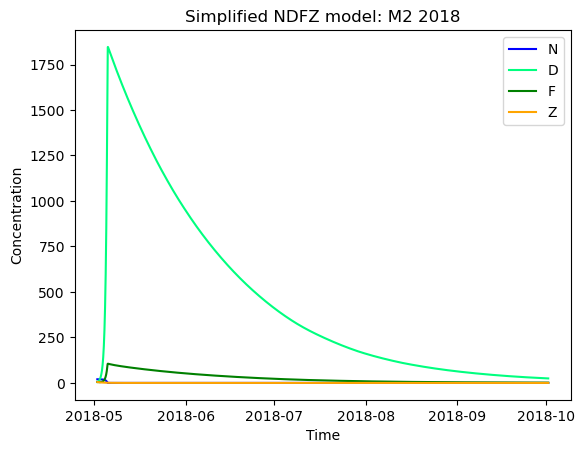

In [158]:
time = M2['time_ak']
plt.plot(time, M2_model.y[0], color='blue') #N
plt.plot(time, M2_model.y[1], color='springgreen') #D
plt.plot(time, M2_model.y[2], color='green') #F
plt.plot(time, M2_model.y[3], color='orange') #Z


plt.title('Simplified NDFZ model: M2 2018')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend(['N', 'D', 'F', 'Z'])